# 04 · The T0 lap solver

T0 is the first solver tier: a **point-mass with a friction ellipse on the 3D ribbon**. Three
sweeps produce the speed profile: a curvature-limited speed at every station, a forward pass
capped by traction and the engine, and a backward pass capped by braking grip. No ODE
integration, no iteration to convergence on open tracks — and strictly deterministic.

The theory page with the full equations: [`docs/theory/t0-point-mass.md`](../docs/theory/t0-point-mass.md).

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap


def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data").is_dir() and (p / "crates").is_dir():
            return p
    raise RuntimeError("run this notebook from inside the outlap repository")


ROOT = _find_root(Path.cwd())

# CI-speed solver pin for this notebook's parameter sweeps: every distinct override/conditions
# combination is a new resolved car and regenerates its g-g-g-v envelope (the cold assembly step),
# so the sweeps here run the point-mass tier on a coarse envelope. The production default
# (tier t1, 40x25x7 grid) is what `solve_lap_dataset(...)` gives with no arguments.
FAST = dict(tier="t0", sim={"envelope": {"v_points": 8, "ax_points": 7, "g_normal_points": 2}})

# Validated reference palette (light mode) — same style as the tour notebook.
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e7e6e2"
BLUE, AQUA, RED = "#2a78d6", "#1baf7a", "#e34948"
LOADS5 = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]  # ordinal, 5 steps
SEQ = LinearSegmentedColormap.from_list(
    "outlap_blue",
    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
)

mpl.rcParams.update(
    {
        "figure.dpi": 115, "figure.facecolor": "white", "axes.facecolor": "white",
        "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
        "axes.titlesize": 12, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
        "axes.spines.top": False, "axes.spines.right": False,
        "xtick.color": INK2, "ytick.color": INK2, "font.size": 10.5,
        "legend.frameon": False, "lines.linewidth": 2.0,
    }
)

try:
    import ipywidgets as widgets  # noqa: F401

    HAVE_WIDGETS = True
except ImportError:
    HAVE_WIDGETS = False
    print("ipywidgets not installed - interactive panels are skipped "
          "(uv sync --group notebooks)")

from outlap.core import Track, min_curvature, solve_lap_dataset

VEH = str(ROOT / "data" / "vehicles" / "f1_2026")
track = Track.load(str(ROOT / "data" / "tracks" / "catalunya_osm"))
rl = min_curvature(track, half_width_m=1.1)
lap = solve_lap_dataset(VEH, rl, **FAST)
print(f"lap {lap.attrs['lap_time_s']:.3f} s")
for note in lap.attrs["notes"]:
    print("  -", note)


lap 110.875 s
  - powertrain tables `tables/ice_v6.parquet` (unit 0) not present — peak-envelope traction only, no energy accounting
  - absent - inflation-pressure terms disabled (dpi = 0, p/p0 = 1)
  - aligning-moment coefficients absent - Mz = 0
  - overturning-moment coefficients absent - Mx = 0
  - rolling-resistance coefficients absent - My = 0
  - ERS modelled as a power cap; per-lap deploy/harvest budgets and override mode are not enforced at T0
  - μ derived from MF6.1 pure-slip peak @ FNOMIN, p_cold (mean of front/rear); braking is friction-limited only at T0
  - absent - inflation-pressure terms disabled (dpi = 0, p/p0 = 1)
  - aligning-moment coefficients absent - Mz = 0
  - overturning-moment coefficients absent - Mx = 0
  - rolling-resistance coefficients absent - My = 0
  - T1 powertrain: traction ceiling = best-gear peak envelope × ratio × mechanical efficiency / wheel radius; the differential torque split enters the trim; efficiency/loss maps (when installed) drive ene

## Where the acceleration lives

Colour the lap by total acceleration |a| = √(a_x² + a_y²): the bright stretches are the
grip-limited zones (corners and brake zones — braking peaks far higher than cornering, which
is why the histogram has a long tail), and the pale stretches are the straights, where the
engine — not grip — is the limit:

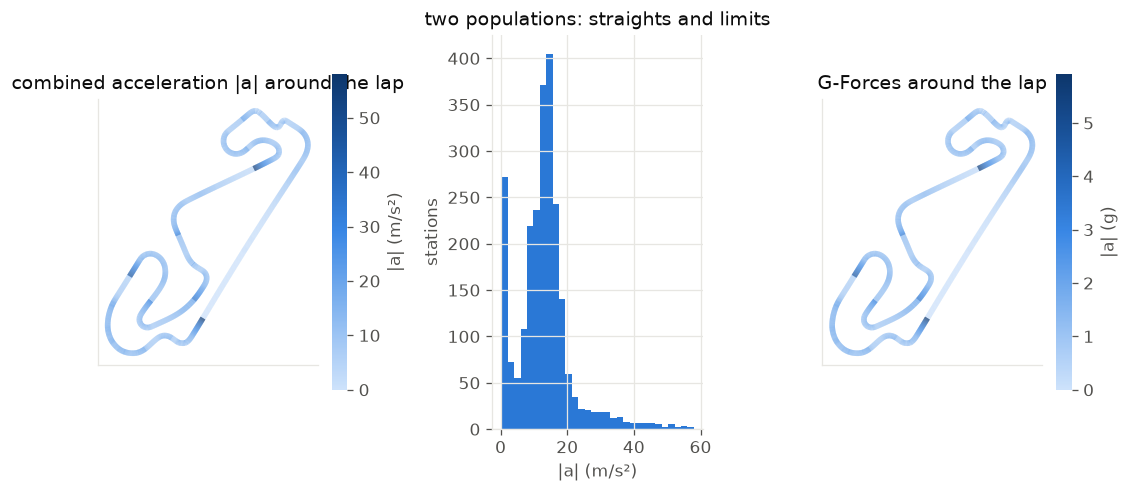

In [2]:
axv, ayv = lap.ax.to_numpy(), lap.ay.to_numpy()
a_tot = np.hypot(axv, ayv)
g     = a_tot/9.81

pts = np.column_stack([lap.x.to_numpy(), lap.y.to_numpy()]).reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc = LineCollection(segs, cmap=SEQ, norm=mpl.colors.Normalize(0, a_tot.max()))
lc.set_array(a_tot[:-1])
lc.set_linewidth(3.5)

lc_g = LineCollection(segs, cmap=SEQ, norm=mpl.colors.Normalize(0, g.max()))
lc_g.set_array(g[:-1])
lc_g.set_linewidth(3.5)

fig, (a, b, c) = plt.subplots(1, 3, figsize=(9.2, 4.4), gridspec_kw={"width_ratios": [1.3, 1, 1.3]})
a.add_collection(lc)
a.set_aspect("equal")
a.autoscale()
a.set_title("combined acceleration |a| around the lap")
a.set_xticks([])
a.set_yticks([])
cb = fig.colorbar(lc, ax=a, shrink=0.8, label="|a| (m/s²)")
cb.outline.set_visible(False)

c.add_collection(lc_g)
c.set_aspect("equal")
c.autoscale()
c.set_title("G-Forces around the lap")
c.set_xticks([])
c.set_yticks([])
cb = fig.colorbar(lc_g, ax=c, shrink=0.8, label="|a| (g)")
cb.outline.set_visible(False)

b.hist(a_tot, bins=30, color=BLUE)
b.set_xlabel("|a| (m/s²)")
b.set_ylabel("stations")
b.set_title("two populations: straights and limits")
plt.tight_layout()
plt.show()

## Discretisation: honest numerics

Fixed-step solvers trade step size against cost. The lap time converges as `ds` shrinks — and
because every pass is a fixed-order sweep with no randomness, the same `ds` always gives the
*same* lap:

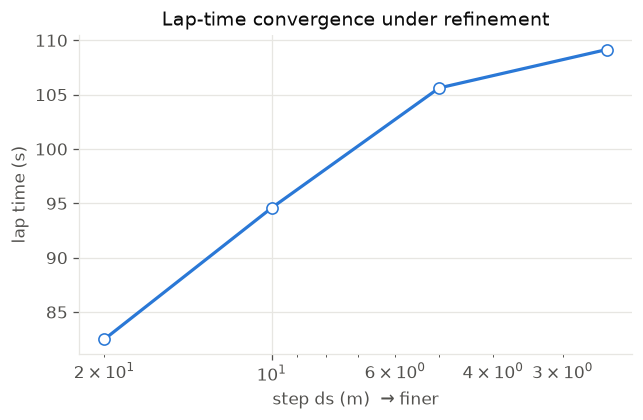

determinism: two identical solves, bit for bit


In [3]:
steps = [20.0, 10.0, 5.0, 2.5]
times = [solve_lap_dataset(VEH, rl, ds_m=d, **FAST).attrs["lap_time_s"] for d in steps]
# Refinement must shrink the increments — a cheap CI tripwire against divergence.
assert abs(times[-1] - times[-2]) < abs(times[1] - times[0])

fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.plot(steps, times, "-o", color=BLUE, ms=7, mfc="white", mec=BLUE)
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_xlabel("step ds (m)  → finer")
ax.set_ylabel("lap time (s)")
ax.set_title("Lap-time convergence under refinement")
plt.show()

t1 = solve_lap_dataset(VEH, rl, ds_m=5.0, **FAST)
t2 = solve_lap_dataset(VEH, rl, ds_m=5.0, **FAST)
assert t1.v.equals(t2.v) and t1.attrs["lap_time_s"] == t2.attrs["lap_time_s"]
print("determinism: two identical solves, bit for bit")

## The session matters

Air density scales both drag and downforce. On a downforce car the two fight: hot, thin air
means less drag on the straights but less grip in the corners. The solver settles the argument:

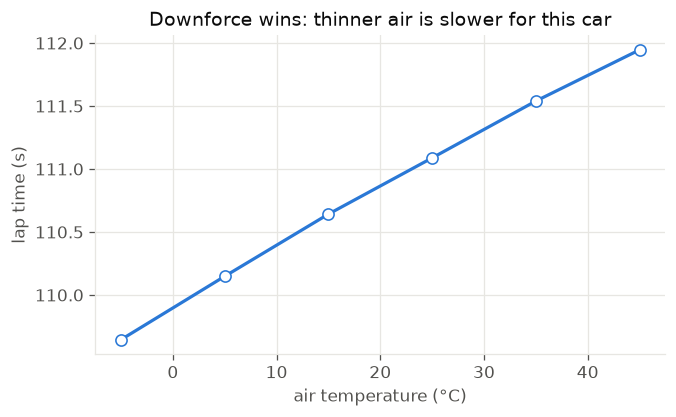

In [4]:
temps = np.array([-5.0, 5.0, 15.0, 25.0, 35.0, 45.0])
lt = [solve_lap_dataset(VEH, rl, **FAST, conditions={"air": {"temperature_c": float(t)}})
      .attrs["lap_time_s"] for t in temps]

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(temps, lt, "-o", color=BLUE, ms=7, mfc="white", mec=BLUE)
ax.set_xlabel("air temperature (°C)")
ax.set_ylabel("lap time (s)")
ax.set_title("Downforce wins: thinner air is slower for this car")
plt.show()

> **▶ Interactive.** The next cell is live only in a running Jupyter (`uv sync --group notebooks`,
> then `uv run --with jupyterlab jupyter lab`). On GitHub you're seeing its static twin above.

interactive(children=(FloatSlider(value=20.0, description='air °C', max=45.0, min=-5.0, step=2.5), FloatSlider…

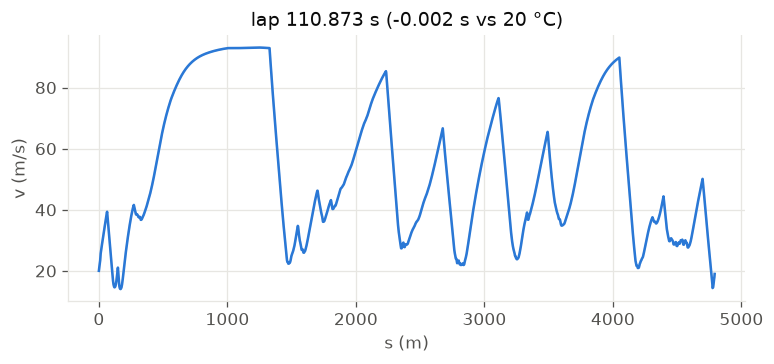

In [5]:
if HAVE_WIDGETS:

    @widgets.interact(
        temp=widgets.FloatSlider(min=-5, max=45, step=2.5, value=20, description="air °C"),
        press=widgets.FloatSlider(min=950, max=1050, step=10, value=1013, description="hPa"),
    )
    def session_lab(temp: float, press: float) -> None:
        lap_w = solve_lap_dataset(
            VEH, rl, **FAST, conditions={"air": {"temperature_c": temp, "pressure_hpa": press}}
        )
        fig, ax = plt.subplots(figsize=(7.6, 3.0))
        ax.plot(lap.s, lap.v, color=GRID, lw=1.2)
        ax.plot(lap_w.s, lap_w.v, color=BLUE, lw=1.6)
        ax.set_xlabel("s (m)"); ax.set_ylabel("v (m/s)")
        ax.set_title(f"lap {lap_w.attrs['lap_time_s']:.3f} s "
                     f"({lap_w.attrs['lap_time_s'] - lap.attrs['lap_time_s']:+.3f} s vs 20 °C)")
        plt.show()

    session_lab(20.0, 1013.0)  # direct call: a real error here must fail CI

**Next:** [05 · the MF6.1 tyre](05_tyre_mf61.ipynb) — the model those accelerations
ultimately come from.